# Steam Roguelike Market Analysis

This project analyzes the growth of roguelike and roguelite games on Steam.

Main questions:
1. How many roguelike games are released each year?
2. How does roguelike compare with other popular Steam tags?
3. What tags commonly appear with roguelike games?
4. Are roguelike games becoming more common over time?

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv(
    r"C:\Users\User\Documents\Documents\DataSets\archive\games.csv"
)

df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime forever,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,8,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...


In [3]:
df.shape
df.columns
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 122611 entries, 0 to 122610
Data columns (total 39 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   AppID                       122611 non-null  int64  
 1   Name                        122610 non-null  str    
 2   Release date                122611 non-null  str    
 3   Estimated owners            122611 non-null  str    
 4   Peak CCU                    122611 non-null  int64  
 5   Required age                122611 non-null  int64  
 6   Price                       122611 non-null  float64
 7   Discount                    122611 non-null  int64  
 8   DLC count                   122611 non-null  int64  
 9   About the game              114162 non-null  str    
 10  Supported languages         122611 non-null  str    
 11  Full audio languages        122611 non-null  str    
 12  Reviews                     12070 non-null   str    
 13  Header image             

AppID                              0
Name                               1
Release date                       0
Estimated owners                   0
Peak CCU                           0
Required age                       0
Price                              0
Discount                           0
DLC count                          0
About the game                  8449
Supported languages                0
Full audio languages               0
Reviews                       110541
Header image                      81
Website                        72935
Support url                    68469
Support email                  22263
Windows                            0
Mac                                0
Linux                              0
Metacritic score                   0
Metacritic url                118355
User score                         0
Positive                           0
Negative                           0
Score rank                    122571
Achievements                       0
R

In [4]:
df["Release date"] = pd.to_datetime(
    df["Release date"],
    errors="coerce"
)

df["Year"] = df["Release date"].dt.year

df[["Name", "Release date", "Year"]].head()

,Name,Release date,Year
0,Black Dragon Mage Playtest,2023-08-01,2023
1,Supipara - Chapter 1 Spring Has Come!,2016-07-29,2016
2,Mystery Solitaire The Black Raven,2019-05-06,2019
3,버튜버 파라노이아 - Vtuber Paranoia,2024-10-31,2024
4,Maze Quest VR,2025-04-24,2025


In [5]:
df = df[df["Year"] < 2025]

In [6]:
roguelike_df = df[
    df["Tags"].str.contains(
        "Roguelike|Rogue-lite|Roguelite|Action Roguelike",
        case=False,
        na=False
    )
].copy()

roguelike_df.head()

,AppID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Year
21,1607040,Evertried,2021-10-21,0 - 20000,0,0,5.99,0,1,"'Every Move Matters' In Evertried, the player’...",...,0,480,0,Lunic Games / Danilo Domingues,DANGEN Entertainment,"Single-player,Full controller support,Family S...","Indie,Strategy","Strategy,Rogue-like,Mystery Dungeon,Rogue-lite...",https://shared.akamai.steamstatic.com/store_it...,2021
26,688420,Bad North: Jotunn Edition,2018-11-16,500000 - 1000000,64,0,2.99,80,1,Position and relocate your troops to fend off ...,...,86,173,139,"Plausible Concept,Oskar Stålberg",Raw Fury,"Single-player,Steam Achievements,Full controll...","Action,Indie,Simulation","Wargame,Vikings,Tower Defense,Real Time Tactic...",https://shared.akamai.steamstatic.com/store_it...,2018
32,2334500,Wizard Shrimp,2024-12-13,0 - 20000,1,0,2.99,0,0,"Wizard Shrimp™ is a bullet-hell, roguelite gam...",...,0,0,0,Wizard Shrimp Games,Wizard Shrimp Games,"Single-player,Steam Achievements,Full controll...","Action,Casual,Indie","Action Roguelike,Casual,Bullet Hell,Magic,Pixe...",https://shared.akamai.steamstatic.com/store_it...,2024
196,2301130,Undead Quest,2023-10-31,0 - 20000,0,0,0.98,0,0,Undead Quest is a VR rogue-lite wave shooter w...,...,0,0,0,Theia Games,Clique Games,"Single-player,Tracked Controller Support,VR On...","Action,Adventure,Casual","FPS,Action,Rogue-lite,Casual,Sports,Shooter,Ar...",https://shared.akamai.steamstatic.com/store_it...,2023
243,2719820,Tafl PTK,2024-02-29,100000 - 200000,0,0,7.99,0,0,Tafl PTK (Protect the King) is a squad formati...,...,0,0,0,Oak The Wise,Oak The Wise,"Single-player,Multi-player,Co-op,Shared/Split ...","Casual,Indie,Strategy,Early Access","Early Access,Casual,Strategy,Auto Battler,Rogu...",https://shared.akamai.steamstatic.com/store_it...,2024


In [7]:
roguelike_df.shape

(5403, 40)

In [8]:
roguelike_yearly = roguelike_df.groupby("Year").size()

roguelike_yearly.head()

Year
2009     1
2010     2
2011     2
2012     6
2013    15
dtype: int64

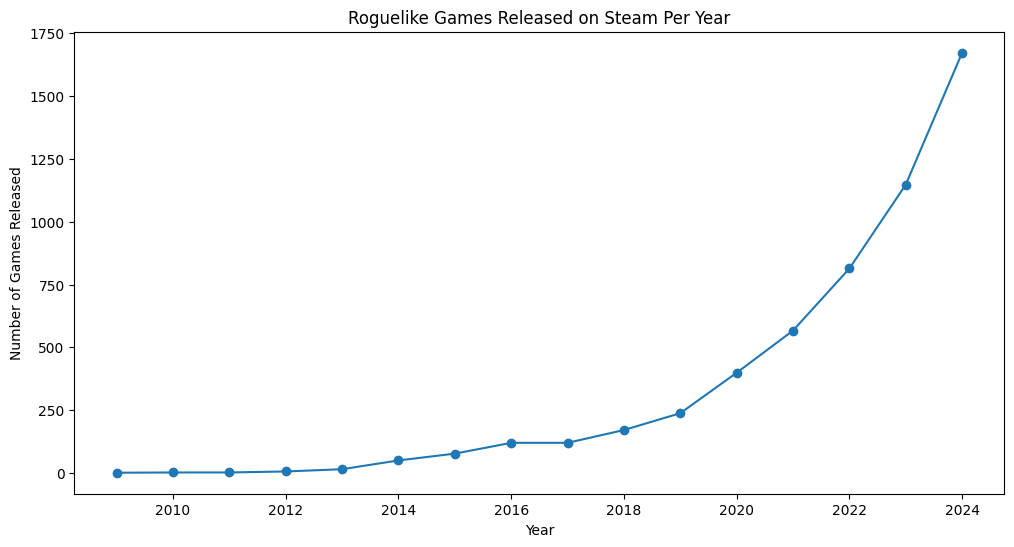

In [9]:
plt.figure(figsize=(12, 6))

plt.plot(
    roguelike_yearly.index,
    roguelike_yearly.values,
    marker="o"
)

plt.title("Roguelike Games Released on Steam Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Games Released")

plt.show()

Roguelike games show clear growth after the early 2010s, with a much stronger increase after 2020.
This suggests that roguelike and roguelite mechanics became increasingly popular on Steam, especially among indie developers.

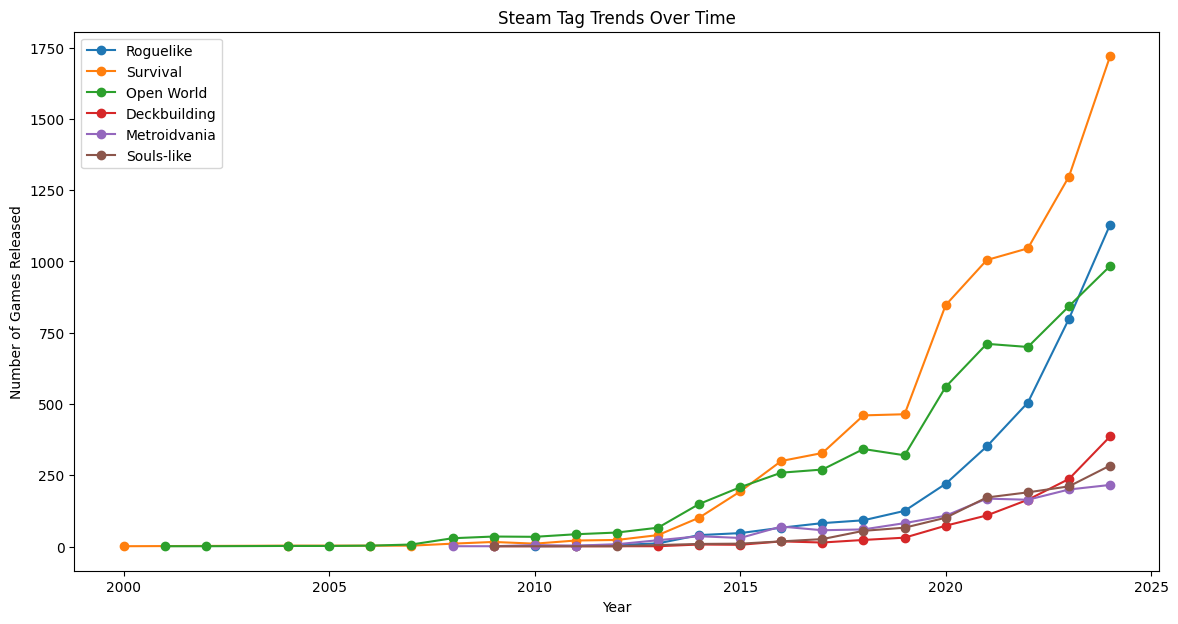

In [10]:
selected_tags = [
    "Roguelike",
    "Survival",
    "Open World",
    "Deckbuilding",
    "Metroidvania",
    "Souls-like"
]

plt.figure(figsize=(14, 7))

for tag in selected_tags:
    tag_df = df[
        df["Tags"].str.contains(
            tag,
            case=False,
            na=False
        )
    ]
    
    yearly_count = tag_df.groupby("Year").size()
    
    plt.plot(
        yearly_count.index,
        yearly_count.values,
        marker="o",
        label=tag
    )

plt.title("Steam Tag Trends Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Games Released")
plt.legend()

plt.show()

Survival is much larger than roguelike because it covers a broader range of games, including open-world survival craft, zombie survival, sandbox survival, and multiplayer survival games.

Roguelike is smaller, but it shows strong growth after 2020.
Deckbuilding also grows noticeably, which may be related to the popularity of roguelike deckbuilders.

In [12]:
tag_counter = Counter()

for tags in roguelike_df["Tags"].dropna():
    for tag in tags.split(","):
        tag_counter[tag.strip()] += 1

roguelike_tags = pd.DataFrame(
    tag_counter.items(),
    columns=["Tag", "Count"]
).sort_values("Count", ascending=False)

roguelike_tags.head(20)

,Tag,Count
3,Rogue-lite,3975
18,Singleplayer,3784
38,Action,3463
1,Rogue-like,3359
24,Action Roguelike,3005
5,2D,2888
19,Indie,2858
75,RPG,2086
7,Pixel Graphics,1950
53,Adventure,1849


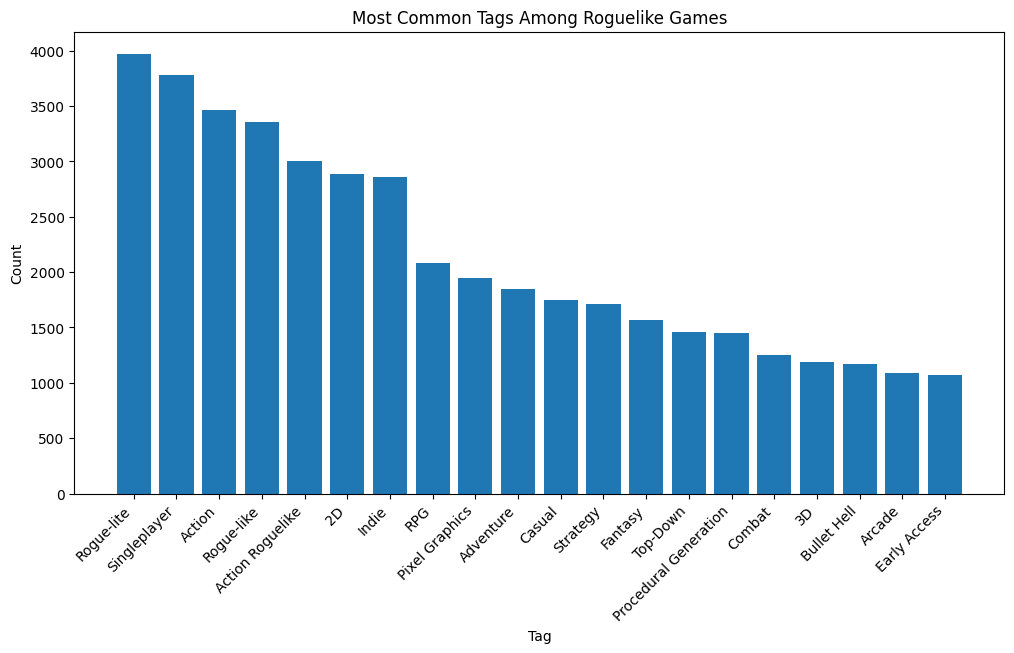

In [13]:
top_roguelike_tags = roguelike_tags.head(20)

plt.figure(figsize=(12, 6))

plt.bar(
    top_roguelike_tags["Tag"],
    top_roguelike_tags["Count"]
)

plt.title("Most Common Tags Among Roguelike Games")
plt.xlabel("Tag")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")

plt.show()

The most common tags show what kind of games are usually associated with roguelike mechanics.
If tags like Indie, Action, RPG, Pixel Graphics, and Difficult appear frequently, it suggests that roguelike is strongly connected with indie action games and challenge-focused gameplay.

In [15]:
roguelike_df["Price"].describe()

count    5403.000000
mean        5.868975
std        15.290459
min         0.000000
25%         1.490000
50%         3.390000
75%         6.340000
max       199.990000
Name: Price, dtype: float64

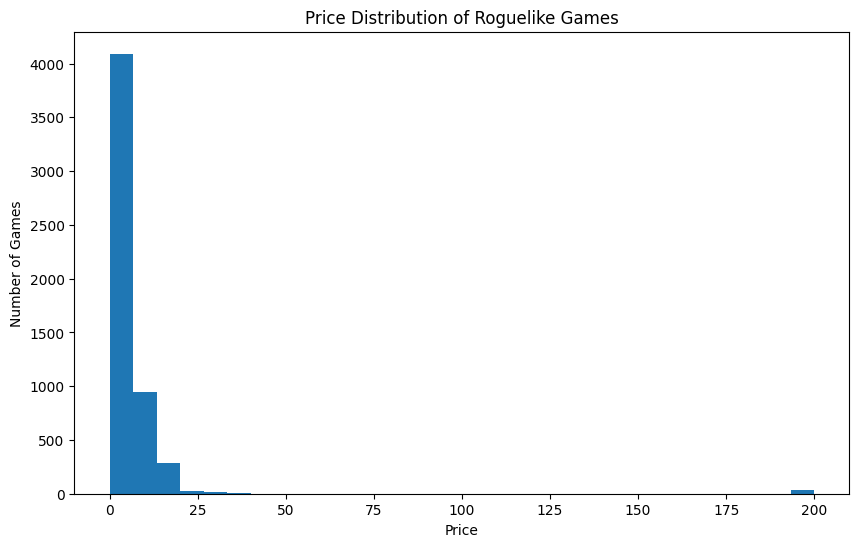

In [16]:
plt.figure(figsize=(10, 6))

plt.hist(
    roguelike_df["Price"].dropna(),
    bins=30
)

plt.title("Price Distribution of Roguelike Games")
plt.xlabel("Price")
plt.ylabel("Number of Games")

plt.show()

Most roguelike games are concentrated in the lower-to-mid price range, which fits the indie game market.
This may suggest that roguelike mechanics are popular among smaller teams because they support replayability without requiring extremely large content production.

In [19]:
roguelike_df["Peak CCU"].describe()

count     5403.000000
mean        28.550620
std        427.104703
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max      17123.000000
Name: Peak CCU, dtype: float64

In [20]:
top_ccu = roguelike_df.sort_values(
    "Peak CCU",
    ascending=False
)[["Name", "Release date", "Peak CCU", "Tags"]].head(10)

top_ccu

,Name,Release date,Peak CCU,Tags
16581,Balatro,2024-02-20,17123,"Card Game,Roguelike Deckbuilder,Rogue-like,Dec..."
81197,Slay the Spire,2019-01-23,15038,"Roguelike Deckbuilder,Card Game,Card Battler,R..."
115665,The Binding of Isaac: Rebirth,2014-11-04,14904,"Action Roguelike,Rogue-like,Indie,Replay Value..."
53561,Risk of Rain 2,2020-08-11,7902,"Third-Person Shooter,Action Roguelike,Multipla..."
88213,Brotato,2023-06-23,6389,"Rogue-like,Singleplayer,Action Roguelike,Bulle..."
99940,Deep Rock Galactic,2020-05-13,5216,"Dwarf,Co-op,PvE,FPS,Procedural Generation,Clas..."
118299,Darkest Dungeon®,2016-01-19,3848,"Turn-Based Combat,Dark Fantasy,Dungeon Crawler..."
104920,The Spell Brigade,2024-09-16,3580,"Action Roguelike,Online Co-Op,Bullet Hell,Rogu..."
86172,DAVE THE DIVER,2023-06-28,3367,"Pixel Graphics,Casual,Management,Adventure,Rel..."
87762,Vampire Survivors,2022-10-20,2966,"Action Roguelike,Bullet Hell,Pixel Graphics,Ro..."


Peak CCU can be used as a rough popularity indicator.
The top games may include outliers, so they should be interpreted carefully.

# Conclusion

This analysis shows that roguelike games have grown significantly on Steam, especially after 2020.

Key findings:

1. Roguelike releases increased strongly after the early 2010s and accelerated after 2020.
2. Survival is still a much larger tag, but roguelike shows a clear upward trend.
3. Roguelike games are strongly connected with indie, action, RPG, difficult, and replayability-focused tags.
4. The genre appears attractive for indie developers because procedural systems and replayability can create long playtime without requiring massive handcrafted content.

Overall, roguelike is not the largest Steam category, but it is one of the most visibly growing indie-friendly design directions.